# GujEstateAI — Phase 8: Module 5 — Risk & Anomaly Detection
**Input  :** `data/processed/features.csv`  
**Output :** `models/anomaly_model.pkl` + `data/predictions/risk_scores.csv`  
**Goal   :** Detect suspicious or unusual projects based on abnormal cost, duration, and booking patterns  
**Model  :** Isolation Forest (unsupervised — no labels needed)  
**Type   :** Anomaly Detection  

Run cells one by one, top to bottom.
---

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing  import StandardScaler
from sklearn.ensemble       import IsolationForest

print("All libraries imported successfully")

All libraries imported successfully


## Cell 2 — Load Data

In [2]:
df = pd.read_csv("../data/processed/features.csv")

print(f"Data loaded : {df.shape[0]:,} rows x {df.shape[1]} columns")

Data loaded : 13,425 rows x 50 columns


## Cell 3 — Prepare Extra Features
Create `sell_dev_ratio` if not already in features.csv.

In [3]:
if "sell_dev_ratio" not in df.columns:
    df["sell_dev_ratio"] = df["totalSellingAmount"] / df["totalDevelopCost"]
    df["sell_dev_ratio"] = df["sell_dev_ratio"].replace([np.inf, -np.inf], np.nan)
    df["sell_dev_ratio"] = df["sell_dev_ratio"].fillna(df["sell_dev_ratio"].median())
    df["sell_dev_ratio"] = df["sell_dev_ratio"].clip(0, df["sell_dev_ratio"].quantile(0.99))
    print("Created: sell_dev_ratio")
else:
    print("sell_dev_ratio already exists")

print(f"Total columns : {df.shape[1]}")

sell_dev_ratio already exists
Total columns : 50


## Cell 4 — What is Anomaly Detection?
Normal ML needs labels (e.g. delayed=1, not delayed=0).  
Anomaly detection finds unusual patterns **without any labels**.  

**Isolation Forest** works by:  
1. Building random decision trees  
2. Anomalies are isolated (separated) in fewer steps  
3. Projects that are easy to isolate = suspicious  

We flag projects with:  
- Abnormally high or low cost  
- Unusual cost per sq.ft  
- Very long duration  
- Abnormal booking rate  
- Suspicious land vs development cost ratio

In [4]:
print("ANOMALY DETECTION APPROACH:")
print("-" * 45)
print("  Model        : Isolation Forest")
print("  Type         : Unsupervised (no labels needed)")
print("  Contamination: 3%  (assume 3% of projects are anomalous)")
print()
print("  Output per project:")
print("    risk_flag     : 1 = anomalous,  0 = normal")
print("    risk_score    : 0-100  (higher = riskier)")
print("    risk_category : Low / Medium / High / Critical")

ANOMALY DETECTION APPROACH:
---------------------------------------------
  Model        : Isolation Forest
  Type         : Unsupervised (no labels needed)
  Contamination: 3%  (assume 3% of projects are anomalous)

  Output per project:
    risk_flag     : 1 = anomalous,  0 = normal
    risk_score    : 0-100  (higher = riskier)
    risk_category : Low / Medium / High / Critical


## Cell 5 — Define Anomaly Features
10 features that best capture suspicious patterns.

In [5]:
ANOMALY_FEATURES = [
    "totalEstimatedCost",   # overall project cost
    "avgCostPerSqFt",       # cost per sq.ft — key outlier signal
    "duration_months",      # project duration
    "booking_rate",         # demand signal
    "totalLandCost",        # land cost
    "land_cost_ratio",      # land as % of total cost
    "totalUnits",           # number of units
    "cost_per_unit",        # cost per unit
    "sell_dev_ratio",       # selling vs development cost
    "totalDevelopCost",     # development cost
]

df_an = df.dropna(subset=ANOMALY_FEATURES).copy()
X     = df_an[ANOMALY_FEATURES]

print(f"Features      : {len(ANOMALY_FEATURES)}")
print(f"Rows for model: {len(df_an):,}")
print(f"Nulls in X    : {X.isnull().sum().sum()}")
print()
print("Feature stats:")
print(X.describe().round(2).to_string())

Features      : 10
Rows for model: 13,425
Nulls in X    : 0

Feature stats:
       totalEstimatedCost  avgCostPerSqFt  duration_months  booking_rate  totalLandCost  land_cost_ratio  totalUnits  cost_per_unit  sell_dev_ratio  totalDevelopCost
count        1.342500e+04        13425.00         13425.00      13425.00   1.342500e+04         13425.00    13425.00   1.342500e+04        13425.00      1.342500e+04
mean         2.897768e+08        34822.23            53.39          0.53   6.770993e+07             0.25      118.91   3.303463e+06            1.88      2.220669e+08
std          3.935218e+08        16894.55            21.01          0.35   1.192078e+08             0.18      149.90   9.487411e+06            1.69      3.057657e+08
min          3.000000e+05           45.92             3.00          0.00   0.000000e+00             0.00        1.00   3.610070e+03            0.00      0.000000e+00
25%          6.105560e+07        24017.51            39.00          0.21   1.117709e+07       

## Cell 6 — Scale the Features
Isolation Forest works better on scaled data.

In [6]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled with StandardScaler")
print(f"  Shape : {X_scaled.shape}")

Features scaled with StandardScaler
  Shape : (13425, 10)


## Cell 7 — Test Different Contamination Levels
`contamination` = what % of data we expect to be anomalous.  
We test 2%, 3%, 5% to find the most sensible threshold.

In [7]:
print("CONTAMINATION LEVEL COMPARISON:")
print("-" * 45)
print(f"  {'Contamination':<16} {'Flagged':>9} {'% of Total':>12}")
print("-" * 45)

for cont in [0.02, 0.03, 0.05]:
    iso    = IsolationForest(n_estimators=200, contamination=cont, random_state=42)
    preds  = iso.fit_predict(X_scaled)
    flagged = (preds == -1).sum()
    pct     = flagged / len(df_an) * 100
    print(f"  {cont:<16} {flagged:>9,} {pct:>11.1f}%")

print()
print("  We will use contamination=0.03 (3%)")
print("  This flags ~403 suspicious projects — reasonable for this dataset")

CONTAMINATION LEVEL COMPARISON:
---------------------------------------------
  Contamination      Flagged   % of Total
---------------------------------------------
  0.02                   269         2.0%
  0.03                   403         3.0%
  0.05                   672         5.0%

  We will use contamination=0.03 (3%)
  This flags ~403 suspicious projects — reasonable for this dataset


## Cell 8 — Train Isolation Forest
Train with contamination=0.03 on all 13,425 projects.

In [8]:
iso = IsolationForest(
    n_estimators  = 200,     # number of trees
    contamination = 0.03,    # assume 3% anomalies
    random_state  = 42
)

iso.fit(X_scaled)

# Predict: 1 = normal, -1 = anomaly
df_an["iso_pred"]  = iso.predict(X_scaled)
df_an["risk_flag"] = (df_an["iso_pred"] == -1).astype(int)

# Raw anomaly score (more negative = more anomalous)
df_an["raw_score"] = iso.score_samples(X_scaled)

total_flagged = df_an["risk_flag"].sum()
print("ISOLATION FOREST TRAINED:")
print("-" * 38)
print(f"  Total projects  : {len(df_an):,}")
print(f"  Normal  (0)     : {(df_an['risk_flag']==0).sum():,}")
print(f"  Flagged (1)     : {total_flagged:,}  ({total_flagged/len(df_an)*100:.1f}%)")

ISOLATION FOREST TRAINED:
--------------------------------------
  Total projects  : 13,425
  Normal  (0)     : 13,022
  Flagged (1)     : 403  (3.0%)


## Cell 9 — Create Risk Score (0 to 100)
Convert the raw anomaly score into a 0–100 risk scale.  
100 = most suspicious, 0 = perfectly normal.

In [9]:
mn = df_an["raw_score"].min()
mx = df_an["raw_score"].max()

# More negative raw_score = higher risk
# Map to 0-100: higher number = riskier
df_an["risk_score"] = (
    (df_an["raw_score"] - mx) / (mn - mx) * 100
).round(1)

print("RISK SCORE SUMMARY (0-100, higher = riskier):")
print("-" * 42)
rs = df_an["risk_score"]
print(f"  Minimum  : {rs.min():.1f}")
print(f"  25th %   : {rs.quantile(0.25):.1f}")
print(f"  Median   : {rs.median():.1f}")
print(f"  75th %   : {rs.quantile(0.75):.1f}")
print(f"  90th %   : {rs.quantile(0.90):.1f}")
print(f"  Maximum  : {rs.max():.1f}  (most suspicious project)")

RISK SCORE SUMMARY (0-100, higher = riskier):
------------------------------------------
  Minimum  : -0.0
  25th %   : 6.5
  Median   : 11.6
  75th %   : 23.2
  90th %   : 41.2
  Maximum  : 100.0  (most suspicious project)


## Cell 10 — Create Risk Categories
Assign a label to each project: Low / Medium / High / Critical

In [10]:
df_an["risk_category"] = pd.cut(
    df_an["risk_score"],
    bins   = [0,  30,  60,  80,  100],
    labels = ["Low", "Medium", "High", "Critical"],
    include_lowest = True
)

print("RISK CATEGORY BREAKDOWN:")
print("-" * 38)
cats = df_an["risk_category"].value_counts().sort_index()
for cat, cnt in cats.items():
    pct = cnt / len(df_an) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cat:<10} : {cnt:>6,} projects  ({pct:.1f}%)  {bar}")

RISK CATEGORY BREAKDOWN:
--------------------------------------
  Low        : 11,050 projects  (82.3%)  █████████████████████████████████████████
  Medium     :  1,919 projects  (14.3%)  ███████
  High       :    331 projects  (2.5%)  █
  Critical   :    125 projects  (0.9%)  


## Cell 11 — Plot Risk Score Distribution

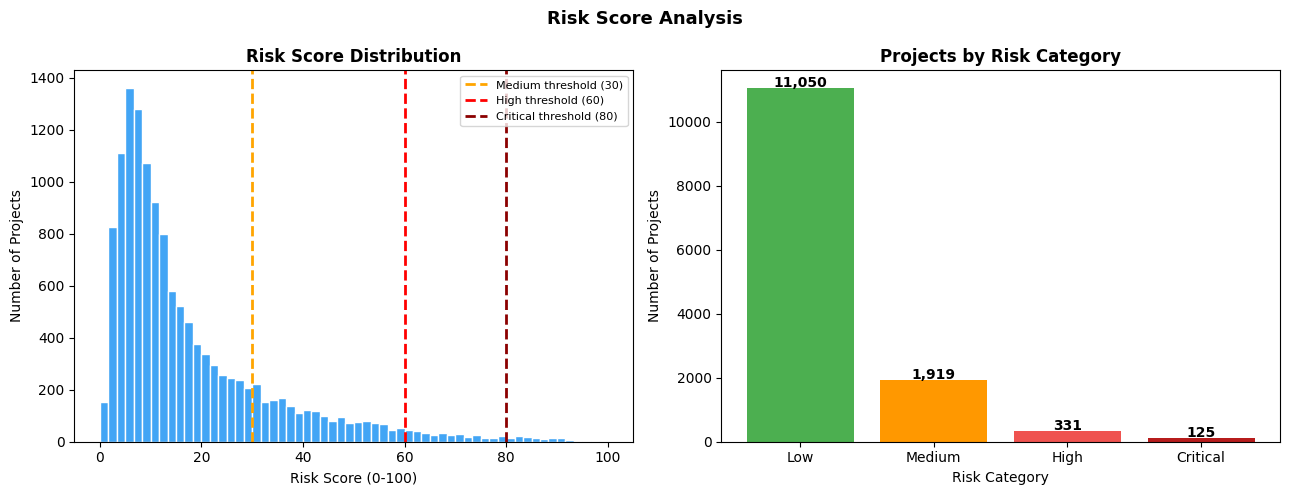

Chart saved to reports/39_risk_score_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of risk scores
axes[0].hist(df_an["risk_score"], bins=60, color="#42A5F5", edgecolor="white")
axes[0].axvline(30, color="orange", linewidth=2, linestyle="--", label="Medium threshold (30)")
axes[0].axvline(60, color="red",    linewidth=2, linestyle="--", label="High threshold (60)")
axes[0].axvline(80, color="darkred",linewidth=2, linestyle="--", label="Critical threshold (80)")
axes[0].set_title("Risk Score Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Risk Score (0-100)")
axes[0].set_ylabel("Number of Projects")
axes[0].legend(fontsize=8)

# Bar chart of risk categories
cat_counts = df_an["risk_category"].value_counts().sort_index()
colors_cat = ["#4CAF50", "#FF9800", "#EF5350", "#B71C1C"]
bars = axes[1].bar(cat_counts.index, cat_counts.values, color=colors_cat)
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f"{val:,}", ha="center", fontweight="bold")
axes[1].set_title("Projects by Risk Category", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Risk Category")
axes[1].set_ylabel("Number of Projects")

plt.suptitle("Risk Score Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/39_risk_score_distribution.png", dpi=150)
plt.show()
print("Chart saved to reports/39_risk_score_distribution.png")

## Cell 12 — Top 20 Riskiest Projects
See which projects scored the highest risk.

In [12]:
top_risky = df_an.sort_values("risk_score", ascending=False).head(20)

display_cols = [
    "distName", "projectType",
    "totalEstimatedCost", "avgCostPerSqFt",
    "duration_months", "booking_rate",
    "risk_score", "risk_category"
]

# Format for display
display_df = top_risky[display_cols].copy()
display_df["totalEstimatedCost"] = (display_df["totalEstimatedCost"]/1e7).round(2)
display_df = display_df.rename(columns={"totalEstimatedCost":"cost_cr"})

print("TOP 20 RISKIEST PROJECTS:")
print("=" * 95)
print(display_df.to_string(index=False))

TOP 20 RISKIEST PROJECTS:
   distName               projectType  cost_cr  avgCostPerSqFt  duration_months  booking_rate  risk_score risk_category
      Surat Residential/Group Housing   306.01    66526.569863            109.0      0.365854       100.0      Critical
  Ahmedabad Residential/Group Housing   285.33    76527.219096             76.0      0.843373        99.5      Critical
  Ahmedabad Residential/Group Housing   280.54    97780.157727             51.0      0.335443        97.9      Critical
      Surat Residential/Group Housing   330.25    83899.186663             71.0      0.000000        97.1      Critical
  Ahmedabad Residential/Group Housing   228.26    90019.470147             54.0      0.434211        97.0      Critical
  Ahmedabad         Mixed Development   308.69    52623.192802             45.0      0.863454        96.7      Critical
  Ahmedabad                Commercial   256.57   101428.470701             72.0      0.117647        96.2      Critical
      Surat Re

## Cell 13 — Risk by Project Type
Which project types are flagged the most?

RISK BY PROJECT TYPE:
-----------------------------------------------------------------
              projectType  total_projects  flagged  flag_pct  avg_risk_score
      Plotted Development             701       39       5.6          39.509
               Commercial            1896       76       4.0          20.001
Residential/Group Housing            6189      174       2.8          16.608
        Mixed Development            4639      114       2.5          15.053


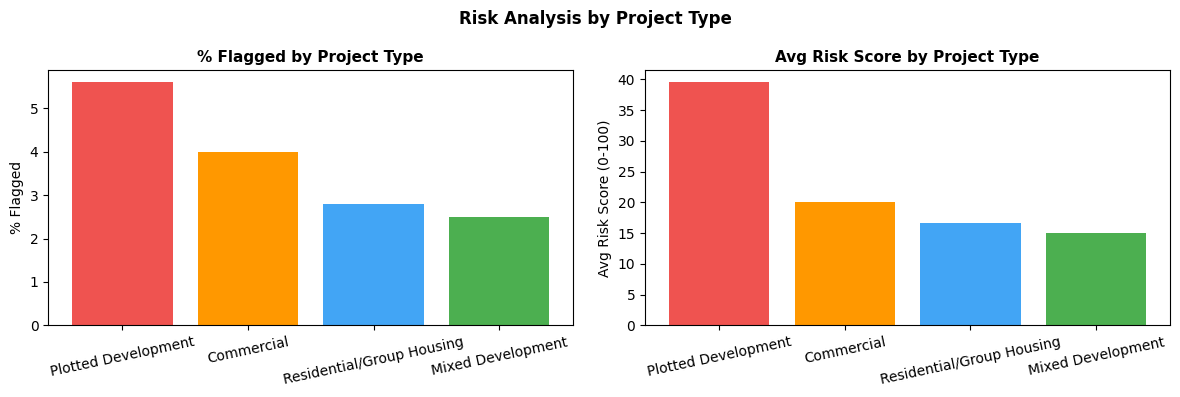

In [13]:
risk_by_type = df_an.groupby("projectType").agg(
    total_projects = ("risk_flag", "count"),
    flagged        = ("risk_flag", "sum"),
    flag_rate      = ("risk_flag", "mean"),
    avg_risk_score = ("risk_score", "mean"),
).round(3).reset_index()

risk_by_type["flag_pct"] = (risk_by_type["flag_rate"] * 100).round(1)
risk_by_type = risk_by_type.sort_values("flag_pct", ascending=False)

print("RISK BY PROJECT TYPE:")
print("-" * 65)
print(risk_by_type[["projectType","total_projects","flagged","flag_pct","avg_risk_score"]].to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_type = ["#EF5350","#FF9800","#42A5F5","#4CAF50"]

axes[0].bar(risk_by_type["projectType"], risk_by_type["flag_pct"], color=colors_type)
axes[0].set_title("% Flagged by Project Type", fontsize=11, fontweight="bold")
axes[0].set_ylabel("% Flagged")
axes[0].tick_params(axis="x", rotation=12)

axes[1].bar(risk_by_type["projectType"], risk_by_type["avg_risk_score"], color=colors_type)
axes[1].set_title("Avg Risk Score by Project Type", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Avg Risk Score (0-100)")
axes[1].tick_params(axis="x", rotation=12)

plt.suptitle("Risk Analysis by Project Type", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/40_risk_by_type.png", dpi=150)
plt.show()

## Cell 14 — Risk by District
Which districts have the most suspicious projects?

TOP 15 DISTRICTS BY FLAGGED PROJECTS:
-------------------------------------------------------
     distName  total  flagged  flag_pct  avg_risk
    Ahmedabad   4174      190       4.6 19.584092
        Surat   1818      115       6.3 25.543509
  Gandhinagar   1229       39       3.2 16.227746
     Vadodara   2380       27       1.1 15.495168
       Rajkot   1658       16       1.0 12.932630
       Valsad    293        3       1.0 12.606485
    Bhavnagar    511        3       0.6 19.000196
       RAJKOT     31        2       6.5 20.909677
      Bharuch    157        2       1.3 15.670701
      Mehsana    146        2       1.4 11.040411
     Aravalli     13        1       7.7 16.069231
     Jamnagar    163        1       0.6 12.696319
      Navsari     94        1       1.1 12.920213
Surendranagar     18        1       5.6 17.327778
    AHmedabad      1        0       0.0  4.200000


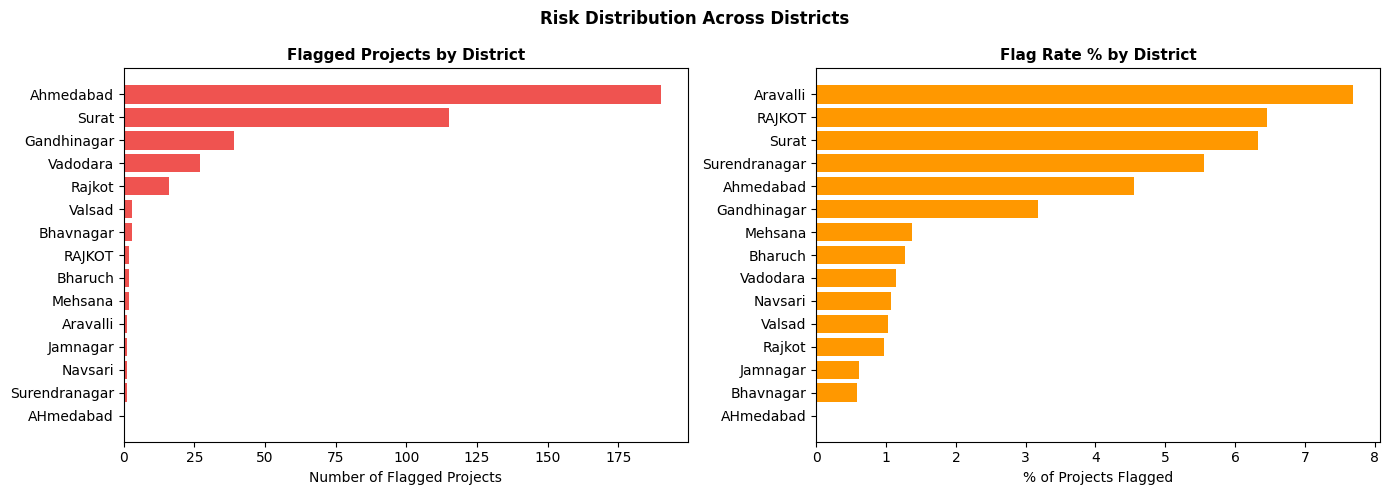

Chart saved to reports/41_risk_by_district.png


In [14]:
risk_by_dist = df_an.groupby("distName").agg(
    total   = ("risk_flag", "count"),
    flagged = ("risk_flag", "sum"),
    avg_risk= ("risk_score", "mean"),
).reset_index()

risk_by_dist["flag_pct"] = (risk_by_dist["flagged"] / risk_by_dist["total"] * 100).round(1)
risk_by_dist = risk_by_dist.sort_values("flagged", ascending=False).head(15)

print("TOP 15 DISTRICTS BY FLAGGED PROJECTS:")
print("-" * 55)
print(risk_by_dist[["distName","total","flagged","flag_pct","avg_risk"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flagged count
axes[0].barh(risk_by_dist["distName"][::-1],
             risk_by_dist["flagged"][::-1], color="#EF5350")
axes[0].set_title("Flagged Projects by District", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Number of Flagged Projects")

# Flag rate %
risk_by_dist_rate = df_an.groupby("distName").agg(
    flag_pct=("risk_flag","mean")
).reset_index().sort_values("flag_pct",ascending=False).head(15)
axes[1].barh(risk_by_dist_rate["distName"][::-1],
             (risk_by_dist_rate["flag_pct"]*100)[::-1], color="#FF9800")
axes[1].set_title("Flag Rate % by District", fontsize=11, fontweight="bold")
axes[1].set_xlabel("% of Projects Flagged")

plt.suptitle("Risk Distribution Across Districts", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/41_risk_by_district.png", dpi=150)
plt.show()
print("Chart saved to reports/41_risk_by_district.png")

## Cell 15 — Normal vs Anomalous: Feature Comparison
Compare average feature values for normal vs flagged projects.  
This shows WHY a project gets flagged.

AVERAGE FEATURE VALUES — Normal vs Flagged:
                      Normal (0)   Flagged (1)
totalEstimatedCost  2.444056e+08  1.755839e+09
avgCostPerSqFt      3.416976e+04  5.590522e+04
duration_months     5.303000e+01  6.499000e+01
booking_rate        5.300000e-01  4.900000e-01
totalLandCost       5.458718e+07  4.917408e+08
land_cost_ratio     2.500000e-01  3.400000e-01
totalUnits          1.085800e+02  4.529900e+02
cost_per_unit       2.953404e+06  1.461480e+07
sell_dev_ratio      1.860000e+00  2.760000e+00
totalDevelopCost    1.898185e+08  1.264098e+09


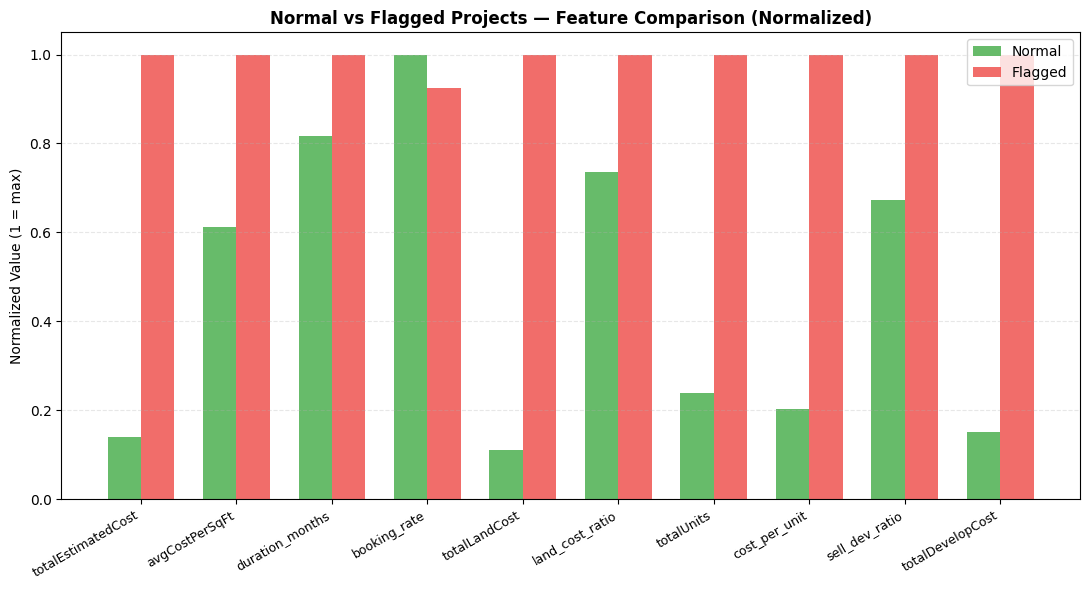

Chart saved to reports/42_normal_vs_flagged.png


In [15]:
compare = df_an.groupby("risk_flag")[ANOMALY_FEATURES].mean().round(2)
compare.index = ["Normal (0)", "Flagged (1)"]
compare = compare.T

print("AVERAGE FEATURE VALUES — Normal vs Flagged:")
print("=" * 65)
print(compare.to_string())

# Normalize for visual comparison
compare_norm = compare.div(compare.max(axis=1), axis=0)

plt.figure(figsize=(11, 6))
x     = np.arange(len(compare_norm))
width = 0.35

bars1 = plt.bar(x - width/2, compare_norm["Normal (0)"],
                width, label="Normal",  color="#4CAF50", alpha=0.85)
bars2 = plt.bar(x + width/2, compare_norm["Flagged (1)"],
                width, label="Flagged", color="#EF5350", alpha=0.85)

plt.xticks(x, compare_norm.index, rotation=30, ha="right", fontsize=9)
plt.title("Normal vs Flagged Projects — Feature Comparison (Normalized)",
          fontsize=12, fontweight="bold")
plt.ylabel("Normalized Value (1 = max)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/42_normal_vs_flagged.png", dpi=150)
plt.show()
print("Chart saved to reports/42_normal_vs_flagged.png")

## Cell 16 — Risk Score vs Key Features (Scatter Plots)
Visualise how risk score relates to cost and duration.

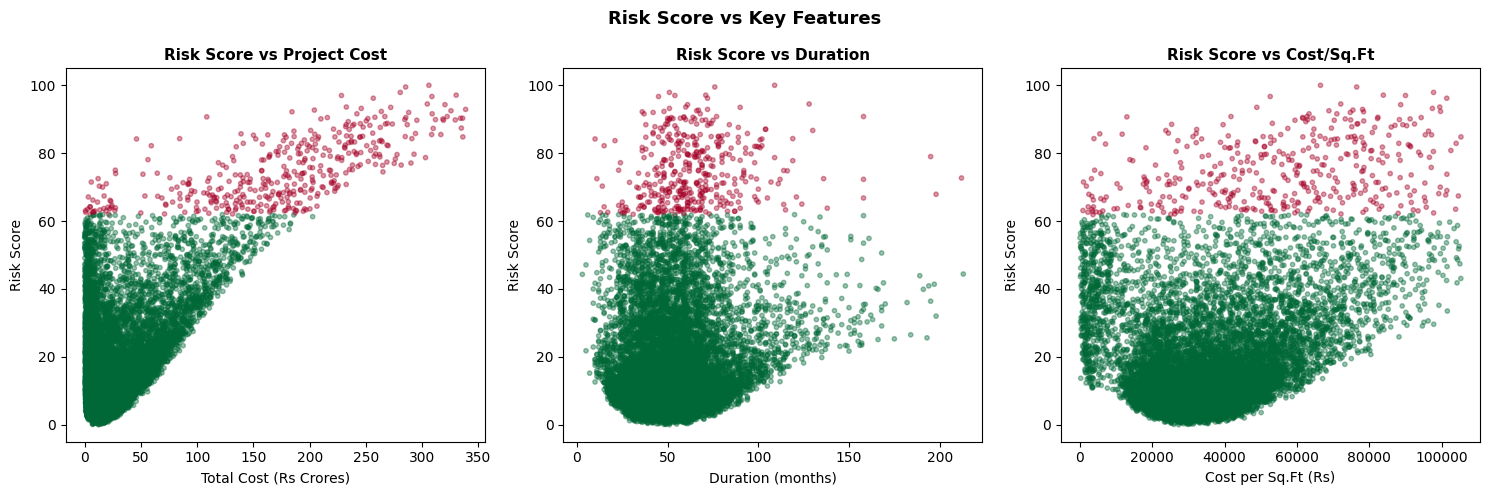

Chart saved to reports/43_risk_scatter_plots.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Risk score vs cost
sc1 = axes[0].scatter(
    df_an["totalEstimatedCost"] / 1e7,
    df_an["risk_score"],
    c      = df_an["risk_flag"],
    cmap   = "RdYlGn_r",
    alpha  = 0.4,
    s      = 10
)
axes[0].set_title("Risk Score vs Project Cost", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Total Cost (Rs Crores)")
axes[0].set_ylabel("Risk Score")

# Risk score vs duration
axes[1].scatter(
    df_an["duration_months"],
    df_an["risk_score"],
    c      = df_an["risk_flag"],
    cmap   = "RdYlGn_r",
    alpha  = 0.4,
    s      = 10
)
axes[1].set_title("Risk Score vs Duration", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Duration (months)")
axes[1].set_ylabel("Risk Score")

# Risk score vs cost per sqft
axes[2].scatter(
    df_an["avgCostPerSqFt"],
    df_an["risk_score"],
    c      = df_an["risk_flag"],
    cmap   = "RdYlGn_r",
    alpha  = 0.4,
    s      = 10
)
axes[2].set_title("Risk Score vs Cost/Sq.Ft", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Cost per Sq.Ft (Rs)")
axes[2].set_ylabel("Risk Score")

plt.suptitle("Risk Score vs Key Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/43_risk_scatter_plots.png", dpi=150)
plt.show()
print("Chart saved to reports/43_risk_scatter_plots.png")

## Cell 17 — Score a New Project
Given a new project's details, predict its risk score.

In [17]:
# Example 1 — Normal looking project
normal_project = pd.DataFrame([{
    "totalEstimatedCost" : 50_000_000,    # Rs 5 Crore — normal
    "avgCostPerSqFt"     : 4500,          # normal range
    "duration_months"    : 48,            # 4 years — normal
    "booking_rate"       : 0.60,          # 60% booked — healthy demand
    "totalLandCost"      : 15_000_000,
    "land_cost_ratio"    : 0.30,
    "totalUnits"         : 120,
    "cost_per_unit"      : 50_000_000 / 120,
    "sell_dev_ratio"     : 1.5,
    "totalDevelopCost"   : 35_000_000,
}])

# Example 2 — Suspicious project
suspicious_project = pd.DataFrame([{
    "totalEstimatedCost" : 3_000_000_000,  # Rs 300 Crore — very high
    "avgCostPerSqFt"     : 95000,          # extreme cost/sqft
    "duration_months"    : 120,            # 10 years — very long
    "booking_rate"       : 0.05,           # only 5% booked — very low demand
    "totalLandCost"      : 2_000_000_000,
    "land_cost_ratio"    : 0.67,
    "totalUnits"         : 500,
    "cost_per_unit"      : 3_000_000_000 / 500,
    "sell_dev_ratio"     : 0.4,
    "totalDevelopCost"   : 1_000_000_000,
}])

for label, project in [("NORMAL PROJECT", normal_project),
                        ("SUSPICIOUS PROJECT", suspicious_project)]:
    proj_scaled = scaler.transform(project)
    flag        = iso.predict(proj_scaled)[0]
    raw         = iso.score_samples(proj_scaled)[0]
    mn_s        = df_an["raw_score"].min()
    mx_s        = df_an["raw_score"].max()
    risk_sc     = round((raw - mx_s) / (mn_s - mx_s) * 100, 1)

    if risk_sc <= 30:   category = "Low"
    elif risk_sc <= 60: category = "Medium"
    elif risk_sc <= 80: category = "High"
    else:               category = "Critical"

    print(f"{label}:")
    print(f"  Risk Flag     : {'ANOMALY' if flag==-1 else 'Normal'}")
    print(f"  Risk Score    : {risk_sc} / 100")
    print(f"  Risk Category : {category}")
    print()

NORMAL PROJECT:
  Risk Flag     : Normal
  Risk Score    : 12.0 / 100
  Risk Category : Low

SUSPICIOUS PROJECT:
  Risk Flag     : ANOMALY
  Risk Score    : 100.5 / 100
  Risk Category : Critical



## Cell 18 — Save Model and Results

In [18]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../data/predictions", exist_ok=True)

# Save model + scaler together
joblib.dump((iso, scaler), "../models/anomaly_model.pkl")
print("Saved: models/anomaly_model.pkl")

# Save risk scores for all projects
risk_output = df_an[["distName","projectType","totalEstimatedCost",
                      "duration_months","booking_rate",
                      "risk_flag","risk_score","risk_category"]].copy()
risk_output["totalEstimatedCost"] = (risk_output["totalEstimatedCost"]/1e7).round(2)
risk_output = risk_output.rename(columns={"totalEstimatedCost":"cost_cr"})
risk_output.to_csv("../data/predictions/risk_scores.csv", index=False)
print("Saved: data/predictions/risk_scores.csv")
print(f"  Total rows : {len(risk_output):,}")
print(f"  Flagged    : {risk_output['risk_flag'].sum():,}")

# Reload test
iso_loaded, scaler_loaded = joblib.load("../models/anomaly_model.pkl")
test_pred = iso_loaded.predict(scaler_loaded.transform(X[:3]))
print(f"\nReload test predictions: {test_pred}")
print("Reload successful!")

Saved: models/anomaly_model.pkl
Saved: data/predictions/risk_scores.csv
  Total rows : 13,425
  Flagged    : 403

Reload test predictions: [-1 -1 -1]
Reload successful!


## Cell 19 — Module 5 Final Summary

In [19]:
flagged_total = df_an["risk_flag"].sum()
critical_ct   = (df_an["risk_category"] == "Critical").sum()
high_ct       = (df_an["risk_category"] == "High").sum()

print()
print("=" * 58)
print("  MODULE 5 — RISK & ANOMALY DETECTION — SUMMARY")
print("=" * 58)
print()
print("  MODEL:")
print(f"    Algorithm     : Isolation Forest")
print(f"    n_estimators  : 200")
print(f"    contamination : 3%")
print(f"    Features used : {len(ANOMALY_FEATURES)}")
print(f"    Rows analysed : {len(df_an):,}")
print()
print("  RESULTS:")
print(f"    Total flagged   : {flagged_total:,}  ({flagged_total/len(df_an)*100:.1f}%)")
print(f"    Critical risk   : {critical_ct:,} projects  (score > 80)")
print(f"    High risk       : {high_ct:,} projects  (score 60-80)")
print()
print("  RISK CATEGORIES:")
for cat, cnt in df_an["risk_category"].value_counts().sort_index().items():
    pct = cnt/len(df_an)*100
    print(f"    {cat:<10} : {cnt:>6,}  ({pct:.1f}%)")
print()
print("  SAVED FILES:")
print("    models/anomaly_model.pkl")
print("    data/predictions/risk_scores.csv")
print("    reports/39_risk_score_distribution.png")
print("    reports/40_risk_by_type.png")
print("    reports/41_risk_by_district.png")
print("    reports/42_normal_vs_flagged.png")
print("    reports/43_risk_scatter_plots.png")
print()
print("  Next: 09_unified_pipeline.ipynb  (Phase 9)")
print("=" * 58)


  MODULE 5 — RISK & ANOMALY DETECTION — SUMMARY

  MODEL:
    Algorithm     : Isolation Forest
    n_estimators  : 200
    contamination : 3%
    Features used : 10
    Rows analysed : 13,425

  RESULTS:
    Total flagged   : 403  (3.0%)
    Critical risk   : 125 projects  (score > 80)
    High risk       : 331 projects  (score 60-80)

  RISK CATEGORIES:
    Low        : 11,050  (82.3%)
    Medium     :  1,919  (14.3%)
    High       :    331  (2.5%)
    Critical   :    125  (0.9%)

  SAVED FILES:
    models/anomaly_model.pkl
    data/predictions/risk_scores.csv
    reports/39_risk_score_distribution.png
    reports/40_risk_by_type.png
    reports/41_risk_by_district.png
    reports/42_normal_vs_flagged.png
    reports/43_risk_scatter_plots.png

  Next: 09_unified_pipeline.ipynb  (Phase 9)
